# Few-shot Multimodal Classification (Fine-tuning)

This notebook is a clean class-based implementation converted from `few_shot.py`.

## Required structure
1. Config Resolve
2. Dataset + EDA
3. Data Loader
4. Pipeline: Input, Preprocess, Backbone, Head, Output
5. Evaluate: Accuracy, Precision, Recall, F1 + Macro metrics
6. Analysis: params, inference time, multimodal confidence

In [1]:
import json
import os
import random
import time
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import torch
import torch.nn as nn
import yaml
from PIL import Image
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm
from transformers import RobertaModel, RobertaTokenizerFast, ViTImageProcessor, ViTModel
from transformers.utils import logging as hf_logging

os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_NO_ADVISORY_WARNINGS", "1")
hf_logging.set_verbosity_error()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## 1) Config Resolve
Resolve data paths, hyperparameters, runtime parameters, and pre-trained model names from `config.yaml`.

In [2]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _resolve_path(base_dir: Path, raw_path: str) -> Path:
    path = Path(raw_path)
    if path.is_absolute():
        return path
    return (base_dir / path).resolve()


@dataclass
class DataConfig:
    train_path: Path
    val_path: Path
    test_path: Path
    images_dir: Path


@dataclass
class ModelConfig:
    vision_model: str
    text_model: str
    freeze_image: bool
    freeze_text: bool
    mlp_hidden_dim: int
    fusion_hidden_dim: int
    dropout: float


@dataclass
class TrainConfig:
    batch_size: int
    epochs: int
    lr: float
    weight_decay: float
    max_text_length: int
    image_size: int
    save_path: Path


@dataclass
class RuntimeConfig:
    seed: int
    batch_size: int
    shots_per_class: int


@dataclass
class AppConfig:
    data: DataConfig
    model: ModelConfig
    train: TrainConfig
    runtime: RuntimeConfig
    labels: List[str]

    @classmethod
    def from_yaml(cls, config_path: str) -> "AppConfig":
        config_file = Path(config_path).resolve()
        with config_file.open("r", encoding="utf-8") as f:
            raw = yaml.safe_load(f)

        if not isinstance(raw, dict):
            raise ValueError("config.yaml must be a YAML mapping")

        base_dir = config_file.parent
        paths = raw.get("paths", {})
        model = raw.get("model", {})
        train = raw.get("training", {})
        runtime = raw.get("runtime", {})
        labels = raw.get("labels", [])

        data_cfg = DataConfig(
            train_path=_resolve_path(base_dir, paths.get("train_path", "")),
            val_path=_resolve_path(base_dir, paths.get("val_path", "")),
            test_path=_resolve_path(base_dir, paths.get("test_path", "")),
            images_dir=_resolve_path(base_dir, paths.get("images_dir", "")),
        )

        model_cfg = ModelConfig(
            vision_model=model.get("vision_model", "google/vit-base-patch16-224-in21k"),
            text_model=model.get("text_model", "roberta-base"),
            freeze_image=bool(model.get("freeze_image", False)),
            freeze_text=bool(model.get("freeze_text", False)),
            mlp_hidden_dim=int(model.get("mlp_hidden_dim", 768)),
            fusion_hidden_dim=int(model.get("fusion_hidden_dim", 512)),
            dropout=float(model.get("dropout", 0.2)),
        )

        train_cfg = TrainConfig(
            batch_size=int(train.get("batch_size", 8)),
            epochs=int(train.get("epochs", 5)),
            lr=float(train.get("lr", 1e-5)),
            weight_decay=float(train.get("weight_decay", 0.01)),
            max_text_length=int(train.get("max_text_length", 512)),
            image_size=int(train.get("image_size", 224)),
            save_path=_resolve_path(base_dir, train.get("save_path", "outputs/best_model.pth")),
        )

        runtime_cfg = RuntimeConfig(
            seed=int(runtime.get("seed", 42)),
            batch_size=int(runtime.get("batch_size", 32)),
            shots_per_class=int(runtime.get("shots_per_class", 100)),
        )

        if not labels:
            raise ValueError("labels must not be empty in config.yaml")

        return cls(data=data_cfg, model=model_cfg, train=train_cfg, runtime=runtime_cfg, labels=labels)

    def validate_paths(self) -> None:
        required_files = [self.data.train_path, self.data.val_path, self.data.test_path]
        for file_path in required_files:
            if not file_path.exists():
                raise FileNotFoundError(f"Missing split file: {file_path}")
        if not self.data.images_dir.exists():
            raise FileNotFoundError(f"Missing images directory: {self.data.images_dir}")

    def summary(self) -> Dict[str, object]:
        return {
            "device": DEVICE,
            "train_path": str(self.data.train_path),
            "val_path": str(self.data.val_path),
            "test_path": str(self.data.test_path),
            "images_dir": str(self.data.images_dir),
            "vision_model": self.model.vision_model,
            "text_model": self.model.text_model,
            "freeze_image": self.model.freeze_image,
            "freeze_text": self.model.freeze_text,
            "epochs": self.train.epochs,
            "train_batch_size": self.train.batch_size,
            "infer_batch_size": self.runtime.batch_size,
            "shots_per_class": self.runtime.shots_per_class,
            "lr": self.train.lr,
            "weight_decay": self.train.weight_decay,
            "num_labels": len(self.labels),
        }


cfg = AppConfig.from_yaml("config.yaml")
cfg.validate_paths()
set_seed(cfg.runtime.seed)

for key, value in cfg.summary().items():
    print(f"{key}: {value}")

device: cuda
train_path: D:\Study\BK-OISP\DLA\Assignment\1\Multimodal\data\news\nytimes_train.json
val_path: D:\Study\BK-OISP\DLA\Assignment\1\Multimodal\data\news\nytimes_dev.json
test_path: D:\Study\BK-OISP\DLA\Assignment\1\Multimodal\data\news\nytimes_test.json
images_dir: D:\Study\BK-OISP\DLA\Assignment\1\Multimodal\data\imgs
vision_model: google/vit-base-patch16-224-in21k
text_model: roberta-base
freeze_image: False
freeze_text: False
epochs: 10
train_batch_size: 8
infer_batch_size: 32
shots_per_class: 100
lr: 1e-05
weight_decay: 0.01
num_labels: 24


## 2) Dataset + EDA
Load NYTimes multimodal records, resolve image-text pairs, and produce basic EDA.

In [3]:
def resolve_image_path(images_dir: Path, image_id: str) -> Optional[Path]:
    if not image_id:
        return None

    image_id = str(image_id)
    direct = images_dir / image_id
    if direct.exists():
        return direct

    with_jpg = images_dir / f"{image_id}.jpg"
    if with_jpg.exists():
        return with_jpg

    for ext in (".jpeg", ".png", ".webp"):
        candidate = images_dir / f"{image_id}{ext}"
        if candidate.exists():
            return candidate

    matches = list(images_dir.glob(f"{image_id}.*"))
    if matches:
        return matches[0]

    return None


class N24NewsDataManager:
    def __init__(self, cfg: AppConfig):
        self.cfg = cfg

    def load_items(self, split_path: Path) -> List[Dict[str, object]]:
        with split_path.open("r", encoding="utf-8") as f:
            records = json.load(f)

        if not isinstance(records, list):
            raise ValueError(f"Expected JSON list in {split_path}")

        items: List[Dict[str, object]] = []
        for idx, row in enumerate(records):
            if not isinstance(row, dict):
                continue

            label = row.get("section")
            if label not in self.cfg.labels:
                continue

            image_path = resolve_image_path(self.cfg.data.images_dir, row.get("image_id"))
            if image_path is None:
                continue

            text_fields = [row.get("headline", ""), row.get("abstract", ""), row.get("caption", "")]
            merged_text = " ".join(part.strip() for part in text_fields if isinstance(part, str) and part.strip())

            items.append(
                {
                    "id": row.get("id", idx),
                    "image": image_path,
                    "text": merged_text if merged_text else " ",
                    "label": label,
                }
            )

        return items

    def sample_few_shot(self, items: List[Dict[str, object]]) -> List[Dict[str, object]]:
        grouped: Dict[str, List[Dict[str, object]]] = defaultdict(list)
        for item in items:
            grouped[str(item["label"])].append(item)

        rng = random.Random(self.cfg.runtime.seed)
        sampled: List[Dict[str, object]] = []
        for _, group in grouped.items():
            local = group[:]
            rng.shuffle(local)
            sampled.extend(local[: self.cfg.runtime.shots_per_class])

        rng.shuffle(sampled)
        return sampled

    @staticmethod
    def eda(items: List[Dict[str, object]]) -> Dict[str, object]:
        labels = [str(item["label"]) for item in items]
        lengths = [len(str(item["text"]).split()) for item in items]

        return {
            "num_samples": len(items),
            "num_classes": len(set(labels)),
            "class_distribution": dict(Counter(labels)),
            "text_len_mean": float(np.mean(lengths)) if lengths else 0.0,
            "text_len_std": float(np.std(lengths)) if lengths else 0.0,
            "text_len_min": int(np.min(lengths)) if lengths else 0,
            "text_len_max": int(np.max(lengths)) if lengths else 0,
        }

    def build_splits(self) -> Dict[str, List[Dict[str, object]]]:
        train_items = self.load_items(self.cfg.data.train_path)
        val_items = self.load_items(self.cfg.data.val_path)
        test_items = self.load_items(self.cfg.data.test_path)
        train_fewshot = self.sample_few_shot(train_items)

        return {
            "train_full": train_items,
            "train_fewshot": train_fewshot,
            "val": val_items,
            "test": test_items,
        }


manager = N24NewsDataManager(cfg)
splits = manager.build_splits()

for split_name in ["train_full", "train_fewshot", "val", "test"]:
    report = manager.eda(splits[split_name])
    print(f"\n[{split_name}]")
    print(f"num_samples: {report['num_samples']}")
    print(f"num_classes: {report['num_classes']}")
    print(f"text_len_mean/std: {report['text_len_mean']:.2f}/{report['text_len_std']:.2f}")
    print(f"text_len_min/max: {report['text_len_min']}/{report['text_len_max']}")

fewshot_counts = Counter(str(item["label"]) for item in splits["train_fewshot"])
print("\nFew-shot samples per class:")
for label in cfg.labels:
    print(f"- {label}: {fewshot_counts.get(label, 0)}")


[train_full]
num_samples: 46603
num_classes: 23
text_len_mean/std: 49.01/12.52
text_len_min/max: 11/183

[train_fewshot]
num_samples: 2300
num_classes: 23
text_len_mean/std: 49.29/12.50
text_len_min/max: 14/119

[val]
num_samples: 5814
num_classes: 23
text_len_mean/std: 48.91/12.29
text_len_min/max: 11/145

[test]
num_samples: 5817
num_classes: 23
text_len_mean/std: 48.95/12.30
text_len_min/max: 13/96

Few-shot samples per class:
- Health: 100
- Books: 100
- Science: 100
- Art & Design: 100
- Television: 100
- Style: 100
- Travel: 100
- Media: 100
- Movies: 100
- Food: 100
- Dance: 100
- Well: 100
- Real Estate: 100
- Fashion: 0
- Economy: 100
- Technology: 100
- Sports: 100
- Your Money: 100
- Theater: 100
- Education: 100
- Opinion: 100
- Automobiles: 100
- Music: 100
- Global Business: 100


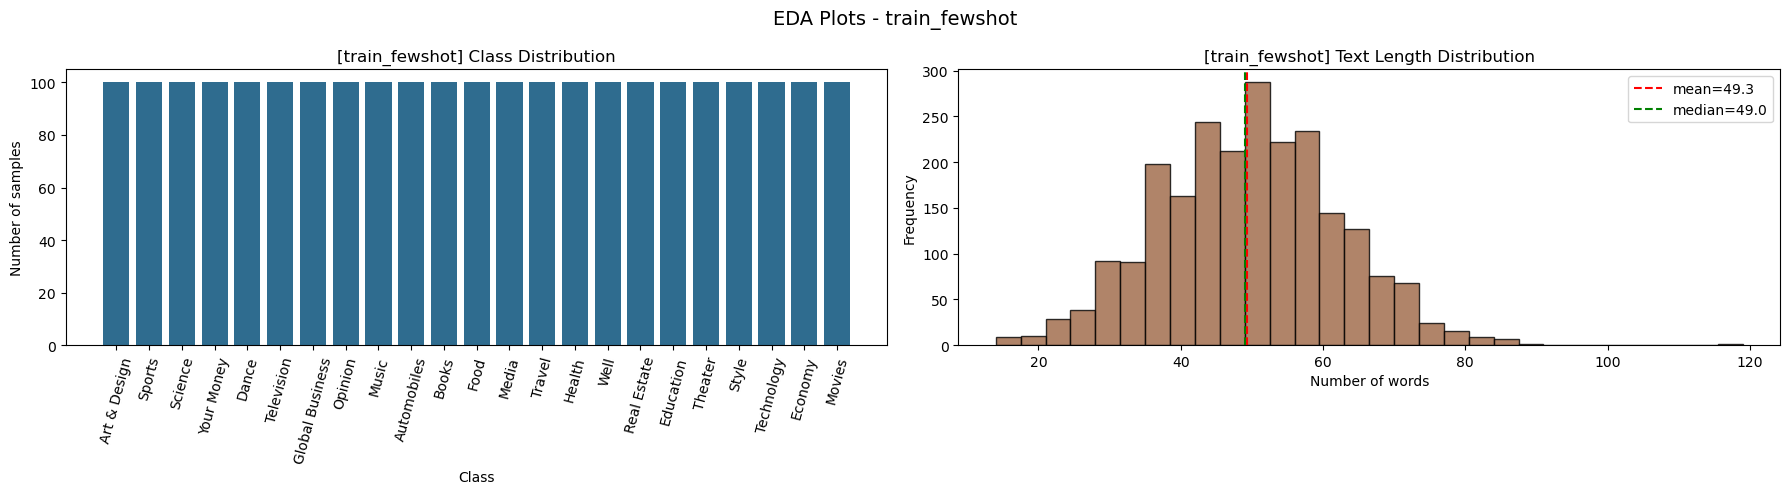

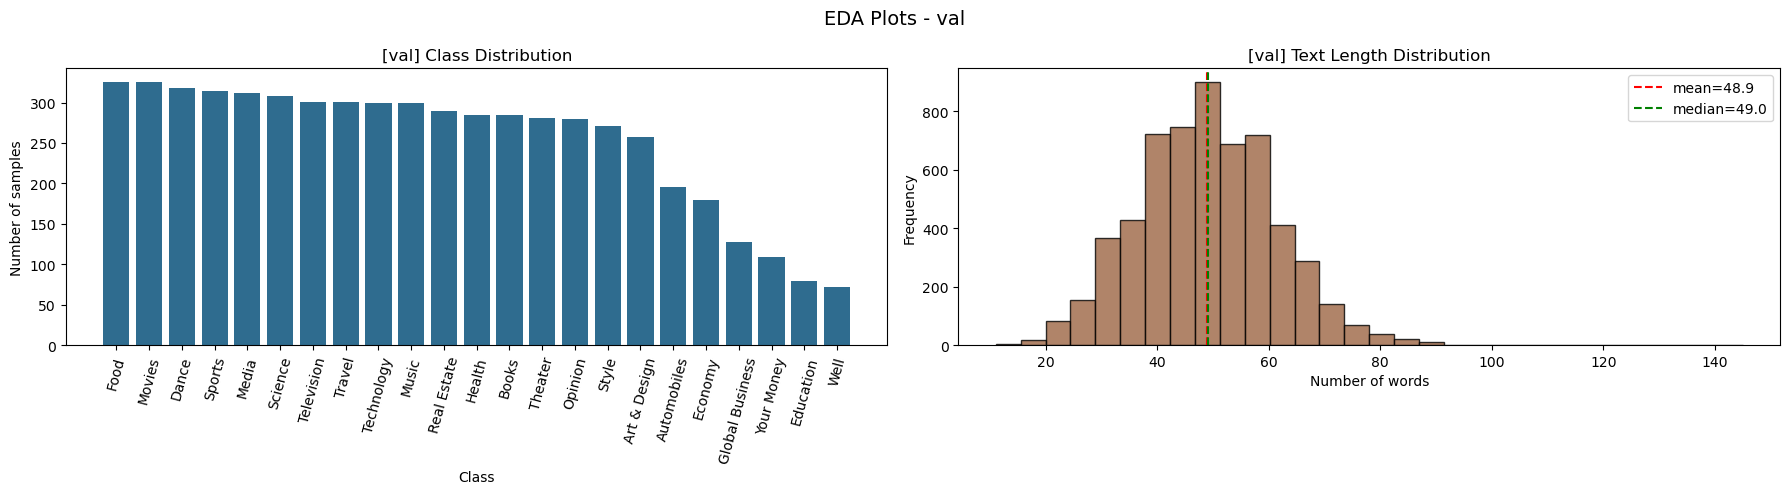

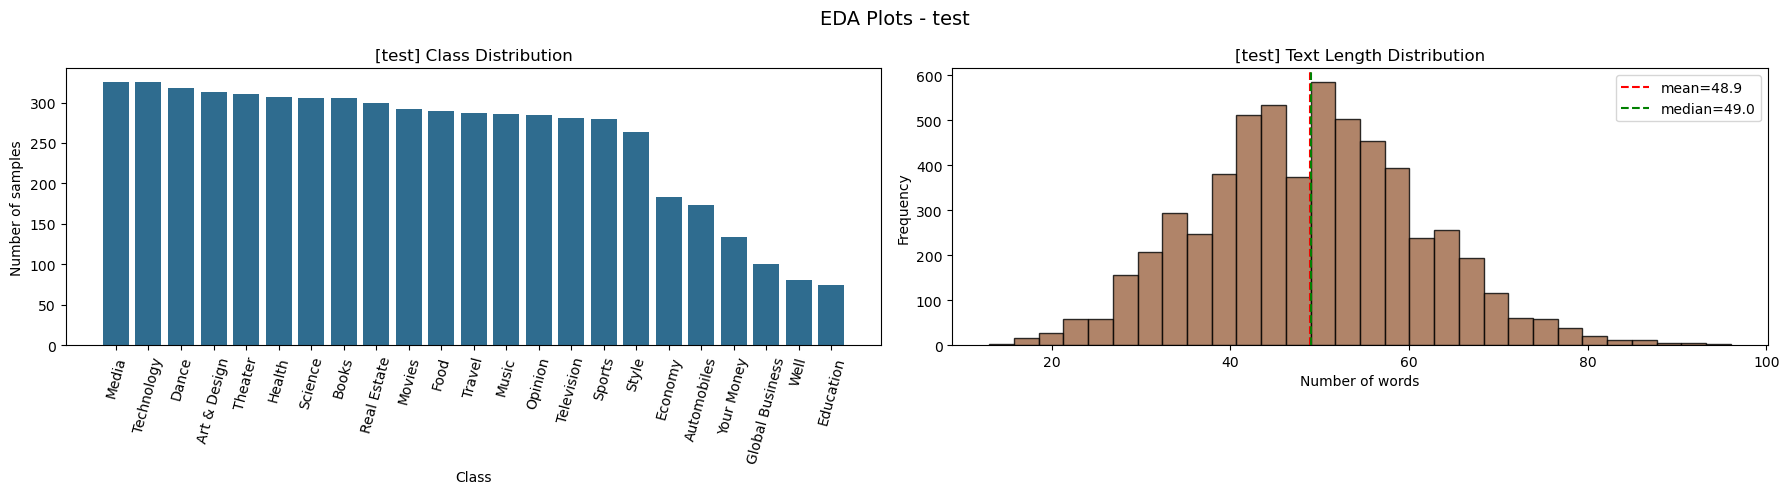

In [9]:
import matplotlib.pyplot as plt


def plot_eda_for_split(split_name: str, items: List[Dict[str, object]]) -> None:
    labels = [str(item["label"]) for item in items]
    text_lengths = [len(str(item["text"]).split()) for item in items]
    class_counts = Counter(labels)

    sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
    class_names = [name for name, _ in sorted_counts]
    sample_counts = [count for _, count in sorted_counts]

    mean_len = float(np.mean(text_lengths)) if text_lengths else 0.0
    median_len = float(np.median(text_lengths)) if text_lengths else 0.0

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    axes[0].bar(class_names, sample_counts, color="#2F6C8F")
    axes[0].set_title(f"[{split_name}] Class Distribution")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Number of samples")
    axes[0].tick_params(axis="x", rotation=75)

    if text_lengths:
        axes[1].hist(text_lengths, bins=30, color="#9C6644", edgecolor="black", alpha=0.8)
    axes[1].set_title(f"[{split_name}] Text Length Distribution")
    axes[1].set_xlabel("Number of words")
    axes[1].set_ylabel("Frequency")
    axes[1].axvline(mean_len, color="red", linestyle="--", linewidth=1.5, label=f"mean={mean_len:.1f}")
    axes[1].axvline(median_len, color="green", linestyle="--", linewidth=1.5, label=f"median={median_len:.1f}")
    axes[1].legend()

    fig.suptitle(f"EDA Plots - {split_name}", fontsize=14)
    plt.tight_layout()
    plt.show()


for split_name in ["train_fewshot", "val", "test"]:
    plot_eda_for_split(split_name, splits[split_name])

### EDA Visualization
Visualize class distribution and text-length distribution for each split (`train_fewshot`, `val`, `test`).

## 3) Data Loader
Create PyTorch dataset and dataloaders for train/val/test.

In [4]:
class N24NewsFewShotDataset(Dataset):
    def __init__(
        self,
        items: List[Dict[str, object]],
        tokenizer: RobertaTokenizerFast,
        image_processor: ViTImageProcessor,
        label2idx: Dict[str, int],
        image_size: int,
        max_text_length: int,
    ):
        self.items = items
        self.tokenizer = tokenizer
        self.label2idx = label2idx
        self.max_text_length = max_text_length

        mean = image_processor.image_mean
        std = image_processor.image_std
        self.transform = transforms.Compose(
            [
                transforms.Resize((image_size, image_size)),
                transforms.ToTensor(),
                transforms.Normalize(mean=mean, std=std),
            ]
        )

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, index: int) -> Dict[str, torch.Tensor]:
        item = self.items[index]

        try:
            image = Image.open(item["image"]).convert("RGB")
        except Exception:
            image = Image.new("RGB", (224, 224), (128, 128, 128))

        pixel_values = self.transform(image)
        encoded = self.tokenizer(
            str(item["text"]),
            truncation=True,
            padding="max_length",
            max_length=self.max_text_length,
            return_tensors="pt",
        )

        return {
            "sample_id": str(item["id"]),
            "pixel_values": pixel_values,
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "label": torch.tensor(self.label2idx[str(item["label"])], dtype=torch.long),
            "label_name": str(item["label"]),
        }


class FewShotDataModule:
    def __init__(self, cfg: AppConfig, splits: Dict[str, List[Dict[str, object]]]):
        self.cfg = cfg
        self.splits = splits

        self.label2idx = {label: idx for idx, label in enumerate(cfg.labels)}
        self.idx2label = {idx: label for label, idx in self.label2idx.items()}

        self.tokenizer = RobertaTokenizerFast.from_pretrained(cfg.model.text_model)
        self.image_processor = ViTImageProcessor.from_pretrained(cfg.model.vision_model)

    def _make_dataset(self, items: List[Dict[str, object]]) -> N24NewsFewShotDataset:
        return N24NewsFewShotDataset(
            items=items,
            tokenizer=self.tokenizer,
            image_processor=self.image_processor,
            label2idx=self.label2idx,
            image_size=self.cfg.train.image_size,
            max_text_length=self.cfg.train.max_text_length,
        )

    def setup(self) -> Dict[str, DataLoader]:
        train_ds = self._make_dataset(self.splits["train_fewshot"])
        val_ds = self._make_dataset(self.splits["val"])
        test_ds = self._make_dataset(self.splits["test"])

        return {
            "train": DataLoader(train_ds, batch_size=self.cfg.train.batch_size, shuffle=True),
            "val": DataLoader(val_ds, batch_size=self.cfg.runtime.batch_size, shuffle=False),
            "test": DataLoader(test_ds, batch_size=self.cfg.runtime.batch_size, shuffle=False),
        }


datamodule = FewShotDataModule(cfg, splits)
loaders = datamodule.setup()
print({name: len(loader.dataset) for name, loader in loaders.items()})

{'train': 2300, 'val': 5814, 'test': 5817}


## 4) Pipeline: Input -> Preprocess -> Backbone -> Head -> Output
Architecture: ViT image branch + RoBERTa text branch + CLS concatenation + 3 MLP heads (image, text, multimodal).

In [5]:
class MLPHead(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class MultimodalFewShotModel(nn.Module):
    def __init__(self, cfg: AppConfig, num_classes: int):
        super().__init__()
        self.cfg = cfg

        # Backbone
        self.vit = ViTModel.from_pretrained(cfg.model.vision_model)
        self.roberta = RobertaModel.from_pretrained(cfg.model.text_model)

        if cfg.model.freeze_image:
            for param in self.vit.parameters():
                param.requires_grad = False
        if cfg.model.freeze_text:
            for param in self.roberta.parameters():
                param.requires_grad = False

        img_dim = int(self.vit.config.hidden_size)
        txt_dim = int(self.roberta.config.hidden_size)

        # Heads
        self.image_head = MLPHead(img_dim, cfg.model.mlp_hidden_dim, num_classes, cfg.model.dropout)
        self.text_head = MLPHead(txt_dim, cfg.model.mlp_hidden_dim, num_classes, cfg.model.dropout)
        self.fusion_head = MLPHead(
            img_dim + txt_dim,
            cfg.model.fusion_hidden_dim,
            num_classes,
            cfg.model.dropout,
        )

    def _encode_image(self, pixel_values: torch.Tensor) -> torch.Tensor:
        out = self.vit(pixel_values=pixel_values, return_dict=True)
        return out.last_hidden_state[:, 0, :]

    def _encode_text(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        out = self.roberta(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        return out.last_hidden_state[:, 0, :]

    def forward(self, pixel_values: torch.Tensor, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> Dict[str, torch.Tensor]:
        # Input + preprocess happen in dataset/dataloader, then backbone here.
        image_cls = self._encode_image(pixel_values)
        text_cls = self._encode_text(input_ids, attention_mask)

        # Feature fusion by concatenation.
        fused_cls = torch.cat([image_cls, text_cls], dim=1)

        # Output heads.
        image_logits = self.image_head(image_cls)
        text_logits = self.text_head(text_cls)
        fusion_logits = self.fusion_head(fused_cls)

        return {
            "image_logits": image_logits,
            "text_logits": text_logits,
            "fusion_logits": fusion_logits,
        }

## 5) Evaluate
Metrics include overall and macro variants: Accuracy, Precision, Recall, F1, Macro Accuracy, Macro Precision, Macro Recall, Macro F1.

In [6]:
def compute_metrics(y_true: List[int], y_pred: List[int]) -> Dict[str, float]:
    if not y_true:
        return {
            "accuracy": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "f1_score": 0.0,
            "macro_accuracy": 0.0,
            "macro_precision": 0.0,
            "macro_recall": 0.0,
            "macro_f1_score": 0.0,
        }

    # Overall metrics are weighted; macro metrics are class-balanced.
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "f1_score": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "macro_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_f1_score": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }


class FewShotTrainer:
    def __init__(self, model: MultimodalFewShotModel, cfg: AppConfig):
        self.model = model
        self.cfg = cfg
        self.criterion = nn.CrossEntropyLoss()

        trainable_params = [p for p in model.parameters() if p.requires_grad]
        self.optimizer = torch.optim.AdamW(
            trainable_params,
            lr=cfg.train.lr,
            weight_decay=cfg.train.weight_decay,
        )

    def _compute_total_loss(self, outputs: Dict[str, torch.Tensor], labels: torch.Tensor) -> torch.Tensor:
        loss_img = self.criterion(outputs["image_logits"], labels)
        loss_txt = self.criterion(outputs["text_logits"], labels)
        loss_fusion = self.criterion(outputs["fusion_logits"], labels)
        return loss_img + loss_txt + loss_fusion

    def train_one_epoch(self, loader: DataLoader, epoch: int) -> float:
        self.model.train()
        losses: List[float] = []

        for batch in tqdm(loader, desc=f"Train epoch {epoch}", leave=False):
            pixel_values = batch["pixel_values"].to(DEVICE)
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            outputs = self.model(pixel_values, input_ids, attention_mask)
            total_loss = self._compute_total_loss(outputs, labels)

            self.optimizer.zero_grad()
            total_loss.backward()
            self.optimizer.step()

            losses.append(float(total_loss.item()))

        return float(np.mean(losses)) if losses else 0.0

    @torch.no_grad()
    def evaluate(self, loader: DataLoader, split_name: str, collect_confidence: bool = False):
        self.model.eval()
        losses: List[float] = []
        y_true: List[int] = []
        y_pred: List[int] = []
        confidence_rows: List[Dict[str, object]] = []

        for batch in tqdm(loader, desc=f"Eval {split_name}", leave=False):
            pixel_values = batch["pixel_values"].to(DEVICE)
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            outputs = self.model(pixel_values, input_ids, attention_mask)
            total_loss = self._compute_total_loss(outputs, labels)
            losses.append(float(total_loss.item()))

            fusion_probs = torch.softmax(outputs["fusion_logits"], dim=1)
            image_probs = torch.softmax(outputs["image_logits"], dim=1)
            text_probs = torch.softmax(outputs["text_logits"], dim=1)

            pred = fusion_probs.argmax(dim=1)
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(pred.cpu().tolist())

            if collect_confidence:
                fusion_conf = fusion_probs.max(dim=1).values.detach().cpu().tolist()
                image_conf = image_probs.max(dim=1).values.detach().cpu().tolist()
                text_conf = text_probs.max(dim=1).values.detach().cpu().tolist()

                sample_ids = list(batch["sample_id"])
                label_names = list(batch["label_name"])

                for i in range(len(sample_ids)):
                    confidence_rows.append(
                        {
                            "sample_id": sample_ids[i],
                            "true_idx": int(labels[i].item()),
                            "pred_idx": int(pred[i].item()),
                            "true_label": label_names[i],
                            "pred_label": datamodule.idx2label[int(pred[i].item())],
                            "image_conf": float(image_conf[i]),
                            "text_conf": float(text_conf[i]),
                            "fusion_conf": float(fusion_conf[i]),
                            "is_correct": bool(int(pred[i].item()) == int(labels[i].item())),
                        }
                    )

        metrics = compute_metrics(y_true, y_pred)
        metrics["loss"] = float(np.mean(losses)) if losses else 0.0
        return metrics, confidence_rows

    def fit(self, train_loader: DataLoader, val_loader: DataLoader) -> None:
        best_val_macro_f1 = -1.0
        self.cfg.train.save_path.parent.mkdir(parents=True, exist_ok=True)

        for epoch in range(1, self.cfg.train.epochs + 1):
            train_loss = self.train_one_epoch(train_loader, epoch=epoch)
            val_metrics, _ = self.evaluate(val_loader, split_name="val", collect_confidence=False)

            print(
                f"Epoch {epoch}/{self.cfg.train.epochs} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_metrics['loss']:.4f} | "
                f"val_acc={val_metrics['accuracy']:.4f} | "
                f"val_macro_f1={val_metrics['macro_f1_score']:.4f}"
            )

            if val_metrics["macro_f1_score"] > best_val_macro_f1:
                best_val_macro_f1 = val_metrics["macro_f1_score"]
                torch.save(self.model.state_dict(), self.cfg.train.save_path)
                print(f"Saved best checkpoint: {self.cfg.train.save_path}")

In [7]:
num_classes = len(cfg.labels)
model = MultimodalFewShotModel(cfg, num_classes=num_classes).to(DEVICE)
trainer = FewShotTrainer(model, cfg)

RUN_TRAINING = False  # Set True to fine-tune on few-shot train split.

if RUN_TRAINING:
    trainer.fit(loaders["train"], loaders["val"])
else:
    print("Skip training. Set RUN_TRAINING=True to fine-tune.")

if cfg.train.save_path.exists():
    print(f"Loading checkpoint: {cfg.train.save_path}")
    model.load_state_dict(torch.load(cfg.train.save_path, map_location=DEVICE))

test_metrics, confidence_rows = trainer.evaluate(loaders["test"], split_name="test", collect_confidence=True)

print("\nTest metrics:")
for key in [
    "loss",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "macro_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1_score",
]:
    print(f"- {key}: {test_metrics[key]:.4f}")

Skip training. Set RUN_TRAINING=True to fine-tune.


Eval test:   0%|          | 0/182 [00:00<?, ?it/s]


Test metrics:
- loss: 9.5356
- accuracy: 0.0535
- precision: 0.0202
- recall: 0.0535
- f1_score: 0.0157
- macro_accuracy: 0.0446
- macro_precision: 0.0173
- macro_recall: 0.0446
- macro_f1_score: 0.0138


## 6) Analysis
- Model size (parameter counts)
- Inference time
- Multimodal confidence analysis

In [8]:
def parameter_report(model: nn.Module) -> Dict[str, object]:
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    approx_size_mb = total_params * 4 / (1024 ** 2)

    return {
        "total_params": int(total_params),
        "trainable_params": int(trainable_params),
        "frozen_params": int(total_params - trainable_params),
        "approx_model_size_mb_fp32": float(approx_size_mb),
    }


@torch.no_grad()
def benchmark_inference_time(model: nn.Module, loader: DataLoader, warmup_batches: int = 2, timed_batches: int = 10) -> Dict[str, float]:
    model.eval()

    # Warm-up for stable timing on GPU kernels.
    warmup_done = 0
    for batch in loader:
        _ = model(
            batch["pixel_values"].to(DEVICE),
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
        )
        warmup_done += 1
        if warmup_done >= warmup_batches:
            break

    latencies: List[float] = []
    num_samples = 0
    timed_done = 0

    for batch in loader:
        start = time.perf_counter()
        _ = model(
            batch["pixel_values"].to(DEVICE),
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
        )
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        end = time.perf_counter()

        batch_size = int(batch["label"].shape[0])
        num_samples += batch_size
        latencies.append(end - start)

        timed_done += 1
        if timed_done >= timed_batches:
            break

    total_time = float(sum(latencies))
    avg_batch_ms = (total_time / max(len(latencies), 1)) * 1000.0
    avg_sample_ms = (total_time / max(num_samples, 1)) * 1000.0

    return {
        "timed_batches": float(len(latencies)),
        "timed_samples": float(num_samples),
        "total_seconds": total_time,
        "avg_batch_ms": avg_batch_ms,
        "avg_sample_ms": avg_sample_ms,
    }


def summarize_confidence(rows: List[Dict[str, object]], top_k: int = 10) -> Dict[str, object]:
    if not rows:
        return {
            "mean_image_conf": 0.0,
            "mean_text_conf": 0.0,
            "mean_fusion_conf": 0.0,
            "mean_fusion_conf_correct": 0.0,
            "mean_fusion_conf_wrong": 0.0,
            "lowest_confidence_samples": [],
        }

    image_vals = [float(r["image_conf"]) for r in rows]
    text_vals = [float(r["text_conf"]) for r in rows]
    fusion_vals = [float(r["fusion_conf"]) for r in rows]

    correct_vals = [float(r["fusion_conf"]) for r in rows if bool(r["is_correct"])]
    wrong_vals = [float(r["fusion_conf"]) for r in rows if not bool(r["is_correct"])]

    low_conf = sorted(rows, key=lambda r: float(r["fusion_conf"]))[:top_k]

    return {
        "mean_image_conf": float(np.mean(image_vals)),
        "mean_text_conf": float(np.mean(text_vals)),
        "mean_fusion_conf": float(np.mean(fusion_vals)),
        "mean_fusion_conf_correct": float(np.mean(correct_vals)) if correct_vals else 0.0,
        "mean_fusion_conf_wrong": float(np.mean(wrong_vals)) if wrong_vals else 0.0,
        "lowest_confidence_samples": low_conf,
    }


param_info = parameter_report(model)
timing_info = benchmark_inference_time(model, loaders["test"])
conf_info = summarize_confidence(confidence_rows, top_k=10)

print("Parameter analysis:")
for k, v in param_info.items():
    print(f"- {k}: {v}")

print("\nInference timing:")
for k, v in timing_info.items():
    if isinstance(v, float):
        print(f"- {k}: {v:.4f}")
    else:
        print(f"- {k}: {v}")

print("\nConfidence summary:")
print(f"- mean_image_conf: {conf_info['mean_image_conf']:.4f}")
print(f"- mean_text_conf: {conf_info['mean_text_conf']:.4f}")
print(f"- mean_fusion_conf: {conf_info['mean_fusion_conf']:.4f}")
print(f"- mean_fusion_conf_correct: {conf_info['mean_fusion_conf_correct']:.4f}")
print(f"- mean_fusion_conf_wrong: {conf_info['mean_fusion_conf_wrong']:.4f}")

print("\nLowest-confidence multimodal predictions:")
for row in conf_info["lowest_confidence_samples"]:
    print(
        f"- id={row['sample_id']} | true={row['true_label']} | pred={row['pred_label']} "
        f"| conf(img/txt/fuse)=({row['image_conf']:.3f}/{row['text_conf']:.3f}/{row['fusion_conf']:.3f}) "
        f"| correct={row['is_correct']}"
    )

Parameter analysis:
- total_params: 213052232
- trainable_params: 213052232
- frozen_params: 0
- approx_model_size_mb_fp32: 812.7297668457031

Inference timing:
- timed_batches: 10.0000
- timed_samples: 320.0000
- total_seconds: 8.1348
- avg_batch_ms: 813.4791
- avg_sample_ms: 25.4212

Confidence summary:
- mean_image_conf: 0.0446
- mean_text_conf: 0.0524
- mean_fusion_conf: 0.0462
- mean_fusion_conf_correct: 0.0462
- mean_fusion_conf_wrong: 0.0462

Lowest-confidence multimodal predictions:
- id=5106 | true=Economy | pred=Opinion | conf(img/txt/fuse)=(0.045/0.053/0.044) | correct=False
- id=5326 | true=Art & Design | pred=Media | conf(img/txt/fuse)=(0.045/0.052/0.044) | correct=False
- id=3444 | true=Health | pred=Opinion | conf(img/txt/fuse)=(0.045/0.052/0.044) | correct=False
- id=4856 | true=Art & Design | pred=Media | conf(img/txt/fuse)=(0.046/0.052/0.044) | correct=False
- id=3472 | true=Sports | pred=Media | conf(img/txt/fuse)=(0.044/0.052/0.044) | correct=False
- id=2160 | true=